# Garbe Kourou download

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [48]:
from tqdm.auto import tqdm

from src.datasources import glofas

In [15]:
lon_guess, lat_guess = 1.625, 13.725
year = 2022

In [19]:
glofas.download_reanalysis_year(
    lon=lon_guess,
    lat=lat_guess,
    year=year,
    pitch=0.5,
    clobber=True,
    centered=True,
)

2025-08-05 14:28:56,429 INFO [2024-09-26T00:00:00] Watch our [Forum]( https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
INFO:ecmwf.datastores.legacy_client:[2024-09-26T00:00:00] Watch our [Forum]( https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-05 14:28:56,940 INFO [2024-02-01T00:00:00] Please note that accessing this dataset via CDS for time-critical operation is not advised or supported
INFO:ecmwf.datastores.legacy_client:[2024-02-01T00:00:00] Please note that accessing this dataset via CDS for time-critical operation is not advised or supported
2025-08-05 14:28:56,943 INFO [2024-02-01T00:00:00] Please note we suggest checking the list of known issues on the GloFAS wiki
[here](https://confluence.ecmwf.int/display/CEMS/GloFAS+-+Known+Issues)
before downloading the dataset.
INFO:ecmwf.datastores.legacy_client:[2024-02-01T00:00:00] Please note we suggest checking the list of known issues on the GloFAS wiki
[here](https://

e846b63bd785273b1ea0c6f4aed73adf.grib:   0%|          | 0.00/216k [00:00<?, ?B/s]

PosixPath('temp/pa-aa-ner-flooding/raw/glofas/reanalysis/glofas_raw_reanalysis_lat13.725_lon1.625_2022.grib')

In [20]:
da_guess = glofas.load_reanalysis_year(
    data_type="raw", lon=lon_guess, lat=lat_guess, year=2022
)

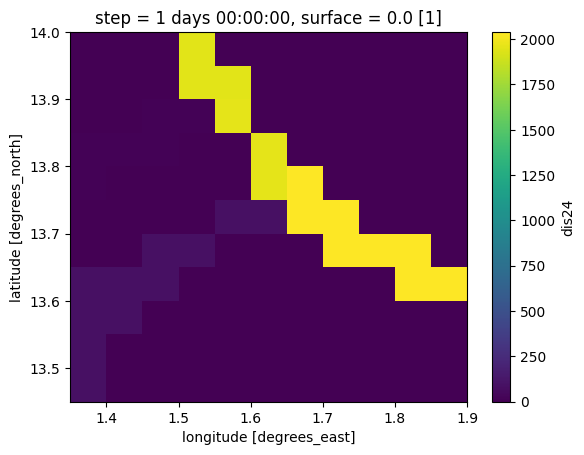

In [42]:
da_guess.mean(dim="time")["dis24"].plot()

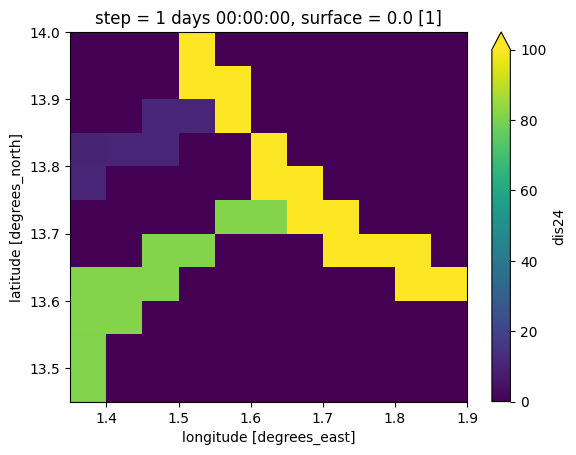

In [24]:
da_guess.mean(dim="time")["dis24"].plot(vmin=0, vmax=100)

In [25]:
da_guess

<xarray.Dataset> Size: 183kB
Dimensions:     (time: 365, latitude: 11, longitude: 11)
Coordinates:
  * time        (time) datetime64[ns] 3kB 2022-01-01 2022-01-02 ... 2022-12-31
    step        timedelta64[ns] 8B 1 days
    surface     float64 8B 0.0
  * latitude    (latitude) float64 88B 13.97 13.92 13.87 ... 13.57 13.52 13.47
  * longitude   (longitude) float64 88B 1.375 1.425 1.475 ... 1.775 1.825 1.875
    valid_time  (time) datetime64[ns] 3kB 2022-01-02 2022-01-03 ... 2023-01-01
Data variables:
    dis24       (time, latitude, longitude) float32 177kB 0.04688 ... 0.007812
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-08-05T14:37 GRIB to CDM+CF via cfgrib-0.9.1...

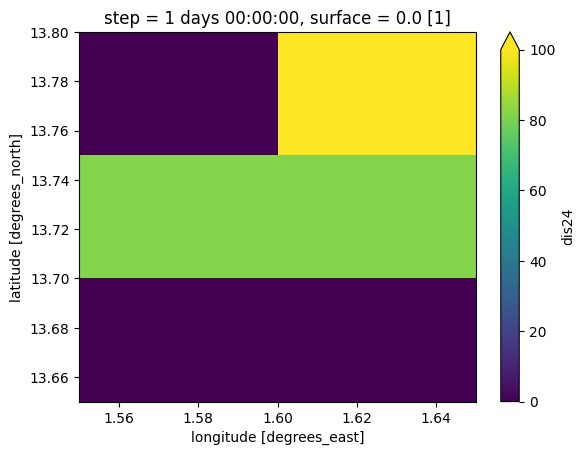

In [38]:
da_guess.sel(latitude=slice(13.78, 13.65), longitude=slice(1.57, 1.63)).mean(
    dim="time"
)["dis24"].plot(vmin=0, vmax=100)

In [39]:
da_guess.sel(latitude=slice(13.78, 13.65), longitude=slice(1.57, 1.63)).mean(
    dim="time"
)

<xarray.Dataset> Size: 80B
Dimensions:    (latitude: 3, longitude: 2)
Coordinates:
    step       timedelta64[ns] 8B 1 days
    surface    float64 8B 0.0
  * latitude   (latitude) float64 24B 13.77 13.72 13.67
  * longitude  (longitude) float64 16B 1.575 1.625
Data variables:
    dis24      (latitude, longitude) float32 24B 0.004302 1.957e+03 ... 0.0598

In [40]:
lon, lat = 1.625, 13.72

In [41]:
glofas.download_reanalysis_year(
    lon=lon,
    lat=lat,
    year=year,
)

2025-08-05 14:44:34,203 INFO [2024-09-26T00:00:00] Watch our [Forum]( https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
INFO:ecmwf.datastores.legacy_client:[2024-09-26T00:00:00] Watch our [Forum]( https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-05 14:44:35,257 INFO [2024-02-01T00:00:00] Please note that accessing this dataset via CDS for time-critical operation is not advised or supported
INFO:ecmwf.datastores.legacy_client:[2024-02-01T00:00:00] Please note that accessing this dataset via CDS for time-critical operation is not advised or supported
2025-08-05 14:44:35,259 INFO [2024-02-01T00:00:00] Please note we suggest checking the list of known issues on the GloFAS wiki
[here](https://confluence.ecmwf.int/display/CEMS/GloFAS+-+Known+Issues)
before downloading the dataset.
INFO:ecmwf.datastores.legacy_client:[2024-02-01T00:00:00] Please note we suggest checking the list of known issues on the GloFAS wiki
[here](https://

c4e8f565f8b04a93af339e4ac84291de.grib:   0%|          | 0.00/87.0k [00:00<?, ?B/s]

PosixPath('temp/pa-aa-ner-flooding/raw/glofas/reanalysis/glofas_raw_reanalysis_lat13.72_lon1.625_2022.grib')

In [43]:
da_better_guess = glofas.load_reanalysis_year(
    data_type="raw", lon=lon, lat=lat, year=2022
)

In [47]:
da_better_guess.mean(dim="time")

<xarray.Dataset> Size: 36B
Dimensions:    (latitude: 1, longitude: 1)
Coordinates:
    step       timedelta64[ns] 8B 1 days
    surface    float64 8B 0.0
  * latitude   (latitude) float64 8B 13.72
  * longitude  (longitude) float64 8B 1.625
Data variables:
    dis24      (latitude, longitude) float32 4B 81.59

In [51]:
station_name = "garbekourou"

In [52]:
for year in tqdm(range(1979, 2025)):
    glofas.download_reanalysis_year(year=year, station_name=station_name)

  0%|          | 0/46 [00:00<?, ?it/s]

2025-08-05 15:01:37,850 INFO [2024-09-26T00:00:00] Watch our [Forum]( https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
INFO:ecmwf.datastores.legacy_client:[2024-09-26T00:00:00] Watch our [Forum]( https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-05 15:01:38,501 INFO [2024-02-01T00:00:00] Please note that accessing this dataset via CDS for time-critical operation is not advised or supported
INFO:ecmwf.datastores.legacy_client:[2024-02-01T00:00:00] Please note that accessing this dataset via CDS for time-critical operation is not advised or supported
2025-08-05 15:01:38,503 INFO [2024-02-01T00:00:00] Please note we suggest checking the list of known issues on the GloFAS wiki
[here](https://confluence.ecmwf.int/display/CEMS/GloFAS+-+Known+Issues)
before downloading the dataset.
INFO:ecmwf.datastores.legacy_client:[2024-02-01T00:00:00] Please note we suggest checking the list of known issues on the GloFAS wiki
[here](https://

905a77bc187d0b2b02f98cfdac8a780e.grib:   0%|          | 0.00/87.0k [00:00<?, ?B/s]

2025-08-05 15:06:13,097 INFO [2024-09-26T00:00:00] Watch our [Forum]( https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
INFO:ecmwf.datastores.legacy_client:[2024-09-26T00:00:00] Watch our [Forum]( https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-05 15:06:13,567 INFO [2024-02-01T00:00:00] Please note that accessing this dataset via CDS for time-critical operation is not advised or supported
INFO:ecmwf.datastores.legacy_client:[2024-02-01T00:00:00] Please note that accessing this dataset via CDS for time-critical operation is not advised or supported
2025-08-05 15:06:13,569 INFO [2024-02-01T00:00:00] Please note we suggest checking the list of known issues on the GloFAS wiki
[here](https://confluence.ecmwf.int/display/CEMS/GloFAS+-+Known+Issues)
before downloading the dataset.
INFO:ecmwf.datastores.legacy_client:[2024-02-01T00:00:00] Please note we suggest checking the list of known issues on the GloFAS wiki
[here](https://

2b092b95d38f88f7075ed27ef840e022.grib:   0%|          | 0.00/87.2k [00:00<?, ?B/s]

...

c4e8f565f8b04a93af339e4ac84291de.grib:   0%|          | 0.00/87.0k [00:00<?, ?B/s]

2025-08-05 20:59:39,176 INFO [2024-09-26T00:00:00] Watch our [Forum]( https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
INFO:ecmwf.datastores.legacy_client:[2024-09-26T00:00:00] Watch our [Forum]( https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-05 20:59:39,641 INFO [2024-02-01T00:00:00] Please note that accessing this dataset via CDS for time-critical operation is not advised or supported
INFO:ecmwf.datastores.legacy_client:[2024-02-01T00:00:00] Please note that accessing this dataset via CDS for time-critical operation is not advised or supported
2025-08-05 20:59:39,644 INFO [2024-02-01T00:00:00] Please note we suggest checking the list of known issues on the GloFAS wiki
[here](https://confluence.ecmwf.int/display/CEMS/GloFAS+-+Known+Issues)
before downloading the dataset.
INFO:ecmwf.datastores.legacy_client:[2024-02-01T00:00:00] Please note we suggest checking the list of known issues on the GloFAS wiki
[here](https://

2b7e903035d316b1b19065270d50f00.grib:   0%|          | 0.00/87.0k [00:00<?, ?B/s]

2025-08-05 21:06:05,190 INFO [2024-09-26T00:00:00] Watch our [Forum]( https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
INFO:ecmwf.datastores.legacy_client:[2024-09-26T00:00:00] Watch our [Forum]( https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-05 21:06:05,816 INFO [2024-02-01T00:00:00] Please note that accessing this dataset via CDS for time-critical operation is not advised or supported
INFO:ecmwf.datastores.legacy_client:[2024-02-01T00:00:00] Please note that accessing this dataset via CDS for time-critical operation is not advised or supported
2025-08-05 21:06:05,818 INFO [2024-02-01T00:00:00] Please note we suggest checking the list of known issues on the GloFAS wiki
[here](https://confluence.ecmwf.int/display/CEMS/GloFAS+-+Known+Issues)
before downloading the dataset.
INFO:ecmwf.datastores.legacy_client:[2024-02-01T00:00:00] Please note we suggest checking the list of known issues on the GloFAS wiki
[here](https://

acf0354aae8a1558d44fff52ab1a9a91.grib:   0%|          | 0.00/87.2k [00:00<?, ?B/s]